<a href="https://colab.research.google.com/github/DannyJung23/SatelliteDataAI-UoA/blob/main/My-Lab-Notebooks/761_Lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning Classifier for Satellite Data

Pre-made training dataset is used to develop a simple deep learning classifier for finding solar pannels in Sentinel-2 imagery.

1. Load and use a pre-labeled training dataset (e.g. polygons or patches with land cover classes)
2. Prepare that data for use in a deep learning model
3. Train a deep learning model in TensorFlow using these labels

### Set up

In [2]:
!pip install -q tensorflow rasterio geemap matplotlib scikit-learn tqdm --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 36.8 MB/s eta 0:00:00


In [3]:
import os
import zipfile
import numpy as np
import math
import re
import rasterio
import cv2
import glob
import matplotlib.pyplot as plt
import tensorflow as tf

from pathlib import Path
from tqdm import tqdm
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from skimage.transform import resize

In [4]:
# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

### Prepare dataset

In [6]:
# Extract the dataset
zip_path = "/content/train.zip"
extract_dir = Path("/content/train_data")
extract_dir.mkdir(parents=True, exist_ok=True)


with zipfile.ZipFile(zip_path, 'r') as z:
  z.extractall(extract_dir)

Build lists of each sample patch and the labelled mask of it, connecting the two.

In [7]:
# Set the file extension
f_ex = "*.tif"

# Locate directories
s2_dir = next((p for p in extract_dir.rglob('*') if p.is_dir() and 's2_image' in p.name.lower()), None)
mask_dir = next((p for p in extract_dir.rglob('*') if p.is_dir() and 'mask' in p.name.lower()), None)

assert s2_dir and mask_dir, "Could not locate s2_image/ and mask/ directories."
print("Found Sentinel-2 image dir:", s2_dir)
print("Found mask dir:", mask_dir)

# Match files to each other from each sub-directory by trailing numeric ID
s2_files = {re.search(r'_(\d+)\.tif$', f.name).group(1): f for f in Path(s2_dir).glob(f_ex)}
mask_files = {re.search(r'_(\d+)\.tif$', f.name).group(1): f for f in Path(mask_dir).glob(f_ex)}

# Build pairs of images and masks
common_ids = sorted(set(s2_files.keys()) & set(mask_files.keys()))
assert len(common_ids) > 0, "No paired s2_image/mask files found with matching IDs."

pairs = []
for i in common_ids:
    s2_path, mask_path = s2_files[i], mask_files[i]
    with rasterio.open(s2_path) as s2, rasterio.open(mask_path) as m:
        assert (s2.height, s2.width) == (m.height, m.width), \
            f"Shape mismatch: {s2_path.name} vs {mask_path.name}"
    pairs.append((s2_path, mask_path))

print(f"Found {len(pairs)} valid paired samples.")
print("Example pair:", pairs[0])

Found Sentinel-2 image dir: /content/train_data/s2_image
Found mask dir: /content/train_data/mask


/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


Found 2066 valid paired samples.
Example pair: (PosixPath('/content/train_data/s2_image/train_s2_image_0.tif'), PosixPath('/content/train_data/mask/train_mask_0.tif'))


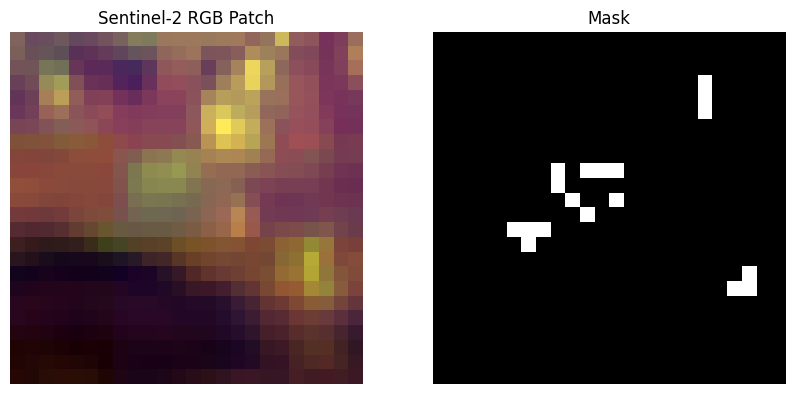

In [8]:
# Quick sanity check: visualize one random pair out of the first 31 available
# Run this cell a few times to check that there are different files and that the mask looks about right
pair_num = np.random.randint(0,30)
s2_path, mask_path = pairs[pair_num]

with rasterio.open(s2_path) as src:
    s2_img = src.read([3,2,1])  # RGB bands for Sentinel-2 (B4, B3, B2)
    s2_img = np.transpose(s2_img, (1,2,0))
    s2_img = (s2_img - s2_img.min()) / (s2_img.max() - s2_img.min())

with rasterio.open(mask_path) as src:
    mask = src.read(1)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(s2_img)
plt.title("Sentinel-2 RGB Patch")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Mask")
plt.axis("off")
plt.show()


### Preprocessing training data

Memory safe approach:
1. Load a batch of patches
2. Normalize/resize them
3. Save them to disk (e.g. as .npy, .npz, or TFRecords/HDF5)
4. Free memory and move on
5. Stream batches directly from disk later when training

In [9]:
# Function to assure all patches are in the right size and shape for the deep learning network
def resize_or_pad(arr, target_h, target_w):
    h, w = arr.shape[:2]
    c = arr.shape[2] if arr.ndim == 3 else 1

    arr = cv2.resize(
        arr,
        (target_w, target_h),
        interpolation=cv2.INTER_NEAREST if c == 1 else cv2.INTER_LINEAR)

    if arr.ndim == 2:
        arr = arr[..., np.newaxis]
    return arr


# Set storage folder
OUTPUT_DIR = "patch_store"
os.makedirs(OUTPUT_DIR, exist_ok=True)

TARGET_HEIGHT, TARGET_WIDTH = 256, 256 # Tune based on memory available
BATCH_SIZE = 100  # Tune based on memory available


X_batch, Y_batch = [], []
batch_idx = 0

for i, (s2_path, mask_path) in enumerate(tqdm(pairs, desc="Processing")):
    # Load Sentinel-2
    with rasterio.open(s2_path) as src:
        img = src.read().astype(np.float32)  # (bands, H, W)
        img = np.transpose(img, (1, 2, 0))  # (H, W, bands)

    # Load mask
    with rasterio.open(mask_path) as src:
        mask = src.read(1).astype(np.uint8)

    # Resize/pad
    img = resize_or_pad(img, TARGET_HEIGHT, TARGET_WIDTH)
    mask = resize_or_pad(mask, TARGET_HEIGHT, TARGET_WIDTH)

    # Normalize
    img = img / 10000.0

    # Add to batch
    X_batch.append(img)
    Y_batch.append(mask)

    # Save batch to disk when full
    if len(X_batch) >= BATCH_SIZE:
        X_batch = np.stack(X_batch)
        Y_batch = np.stack(Y_batch)

        np.savez_compressed(
            os.path.join(OUTPUT_DIR, f"batch_{batch_idx:04d}.npz"),
            X=X_batch, Y=Y_batch
        )

        # Reset
        batch_idx += 1
        X_batch, Y_batch = [], []

# Save any leftovers
if len(X_batch) > 0:
    X_batch = np.stack(X_batch)
    Y_batch = np.stack(Y_batch)
    np.savez_compressed(
        os.path.join(OUTPUT_DIR, f"batch_{batch_idx:04d}.npz"),
        X=X_batch, Y=Y_batch
    )

Processing: 100%|██████████| 2066/2066 [08:15<00:00,  4.17it/s]


In [10]:
# Paramaters for RAM saving
TARGET_HEIGHT, TARGET_WIDTH = 128, 128  # smaller patch -> saves RAM & compute
BANDS = 3  # RGB only -> reduces memory
BATCH_SIZE = 4  # small batch -> reduces RAM usage
MAX_TRAIN_FILES = 5  # only use subset for lab demonstration
MAX_VAL_FILES = 2

Q1: We have used three bands here. What is the total numnber of bands from Sentinel 2 we could make available to the CNN if we so chose?

In [11]:
# Locate the batched .npz files
all_files = sorted(glob.glob("patch_store/*.npz"))
np.random.shuffle(all_files)

train_files = all_files[:MAX_TRAIN_FILES]
val_files   = all_files[-MAX_VAL_FILES:]

Q2: What is the total number of patches in our training data and the total number in our validation set?

Function to change masks to binary labels

In [12]:
def mask_to_label(mask_batch):
    """1 if any solar pixel in mask, else 0"""
    labels = (np.sum(mask_batch, axis=(1,2,3)) > 0).astype(np.float32)
    return labels

Function to load data in from the batched files

In [13]:
def npz_loader_cls(path):
    """Load one .npz batch, downsample patches, convert to RGB, convert mask to label"""
    data = np.load(path.numpy().decode("utf-8"))
    X = data["X"]
    Y_mask = data["Y"]

    # RAM saving: pick first 3 bands only
    X = X[..., :BANDS]

    # RAM saving: downsample patches
    X_resized = np.zeros((X.shape[0], TARGET_HEIGHT, TARGET_WIDTH, BANDS), dtype=np.float32)
    for i in range(X.shape[0]):
        X_resized[i] = resize(X[i], (TARGET_HEIGHT, TARGET_WIDTH, BANDS), anti_aliasing=True)

    X = X_resized

    Y = mask_to_label(Y_mask)
    return X, Y

### Define training and validation datasets

Builds a memory-efficient TensorFlow input pipeline that streams image patches and labels from the compressed .npz files on disk, converts file-level batches into individual samples, shuffles and rebatches them for training, and prefetches data for efficient CNN training.

In [14]:
# TensorFlow dataset pipeline
def tf_wrapper(path):
    X, Y = tf.py_function(npz_loader_cls, [path], [tf.float32, tf.float32])
    X.set_shape([None, TARGET_HEIGHT, TARGET_WIDTH, BANDS])
    Y.set_shape([None])
    # Flatten file-batch into individual samples
    return tf.data.Dataset.from_tensor_slices((X, Y))

def make_cls_dataset(file_list, batch_size=BATCH_SIZE, shuffle=True, repeat=True):
    files = tf.data.Dataset.from_tensor_slices(file_list)
    if shuffle:
        files = files.shuffle(len(file_list))

    # RAM saving: stream samples via interleave
    ds = files.interleave(
        lambda f: tf_wrapper(f),
        cycle_length=4,
        num_parallel_calls=tf.data.AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(2048)

    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    if repeat:
        ds = ds.repeat()

    return ds

train_ds = make_cls_dataset(train_files, batch_size=BATCH_SIZE, shuffle=True)
val_ds   = make_cls_dataset(val_files, batch_size=BATCH_SIZE, shuffle=False, repeat=False)

Q3: Are we shuffling the training dataset? Are we shuffling the validation dataset?

### Define CNN model

In [15]:
# Determining the input shape from one batch first
for X_sample, _ in train_ds.take(1):
    input_shape = X_sample.shape[1:]  # (H, W, bands)
    break

# Define a simple CNN
inputs = layers.Input(shape=input_shape)
x = layers.Conv2D(16, 3, activation='relu', padding='same')(inputs)
x = layers.MaxPooling2D((2,2))(x)
x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(32, activation='relu')(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs, outputs)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,177 (24.13 KB)

 Trainable params: 6,177 (24.13 KB)

 Non-trainable params: 0 (0.00 B)

Q4: Which type of activation function is our final layer using and why are we using this function as our final layer?

Count the actual number of image patches contained in the selected training and validation .npz files, then divide those counts by the mini-batch size to determine how many batches (steps) should be processed during each training epoch and validation cycle.

In [16]:
# Count the total samples
def count_samples(files):
    total = 0
    for f in files:
        total += np.load(f)["X"].shape[0]
    return total

n_train = count_samples(train_files)
n_val   = count_samples(val_files)

steps_per_epoch = max(1, n_train // BATCH_SIZE)
validation_steps = max(1, n_val // BATCH_SIZE)

### Train the model

In [17]:
# This 'callbacks' set of instructions is a handy way to avoid wasting time
callbacks = [
    EarlyStopping(
        monitor="val_loss",          # Watch the validation loss
        patience=3,                  # If it doesn't improve for 3 epochs, stop training
        restore_best_weights=True    # Roll back to the best-performing weights
    )]

# Run the model
history = model.fit(
    train_ds,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_ds,
    validation_steps=validation_steps,
    epochs=5,  # small number for lab demonstration
    callbacks=callbacks)

Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 39s 160ms/step - accuracy: 0.9260 - loss: 0.3305 - val_accuracy: 0.9150 - val_loss: 0.2975
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 28s 155ms/step - accuracy: 0.9340 - loss: 0.2605 - val_accuracy: 0.9150 - val_loss: 0.2997
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 29s 159ms/step - accuracy: 0.9340 - loss: 0.2598 - val_accuracy: 0.9150 - val_loss: 0.2965
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 29s 159ms/step - accuracy: 0.9340 - loss: 0.2560 - val_accuracy: 0.9150 - val_loss: 0.3077
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 29s 154ms/step - accuracy: 0.9340 - loss: 0.2567 - val_accuracy: 0.9150 - val_loss: 0.3150


Visualise the predictions.

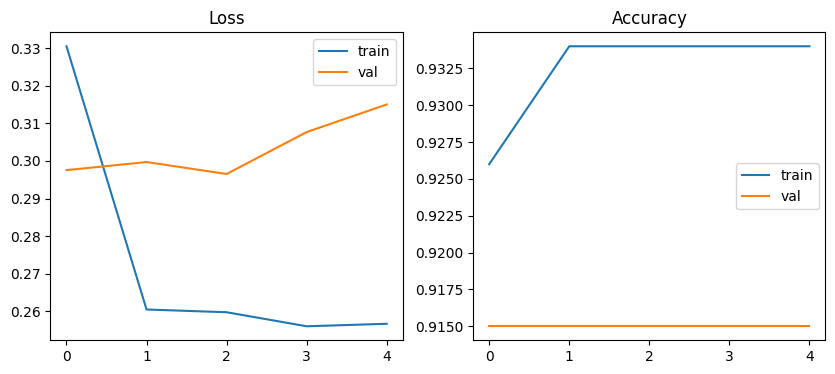

In [18]:
# Plot the training curves
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label="train")
plt.plot(history.history['val_loss'], label="val")
plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label="train")
plt.plot(history.history['val_accuracy'], label="val")
plt.title("Accuracy")
plt.legend()
plt.show()

Display predictions in a grid: n_rows x n_cols. Includes histogram stretch for better visualization of RGB patches.

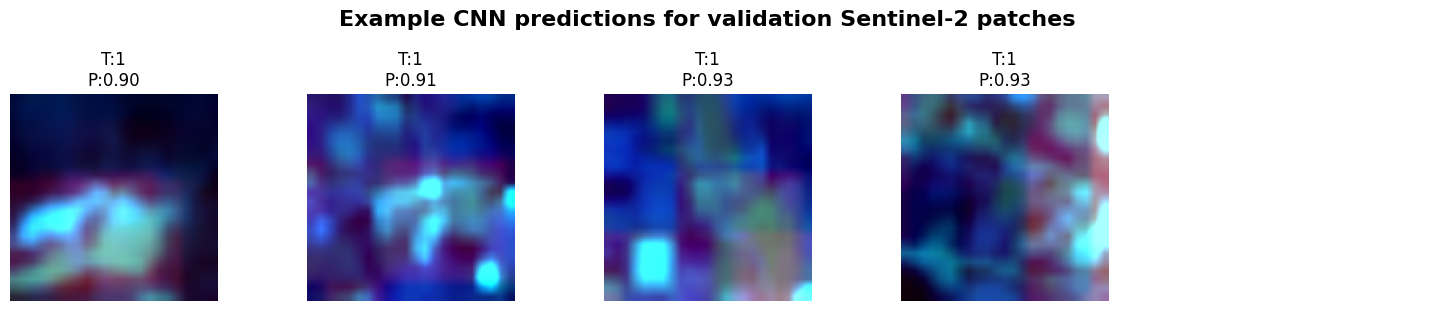

In [19]:
def show_patch_predictions_grid(dataset, model, n_rows=2, n_cols=5):

    def stretch(img):
        # Contrast stretch to 0–1 for display
        img = img.astype(np.float32)
        p2, p98 = np.percentile(img, (2, 98))
        img = np.clip((img - p2) / (p98 - p2 + 1e-6), 0, 1)
        return img

    for X, Y_true in dataset.take(1):
        # live classification of the patch using the trained model
        Y_pred = model.predict(X, verbose=0)
        n_total = min(n_rows * n_cols, X.shape[0])

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*3, n_rows*3))
        axes = axes.flatten()

        for i in range(n_total):
            rgb = X[i, :, :, :3].numpy()
            rgb = stretch(rgb)  # apply histogram stretch
            axes[i].imshow(rgb)
            axes[i].set_title(f"T:{int(Y_true[i].numpy())}\nP:{Y_pred[i,0]:.2f}")
            axes[i].axis("off")

        # hide any unused axes
        for i in range(n_total, len(axes)):
            axes[i].axis("off")

        fig.suptitle(
            "Example CNN predictions for validation Sentinel-2 patches",
            fontsize=16,
            fontweight="bold",
            y=1.02
        )
        plt.tight_layout()
        plt.show()

# Example
show_patch_predictions_grid(val_ds, model, n_rows=1, n_cols=5)

Q5: Is this a robust and reliable model for the detection of solar panels in a new Sentinel 2 image that has never been seen by the model before? Explain your answer with reference to the design of the training data, the settings of the CNN and the performance statistics seen.

Q6: Exercise: using the materials taught in Lab 3 and given your answer to Q5, re-design your training data so that it is a robust training set for the detection of solar panels in S2 data. Your answer needs to include:

- A paragraph that explains what you have added to the train_data and any other steps taken in order to enhance the robustness of the training.
- A figure that demonstrates your newly added patches vs. the existing patches (remember that it needs to be publication quality).

## Code for Q6

**Approach:**
- **Diagnose the original training-data bias:** Confirm the strong class imbalance identified in Q5, with the original source patches dominated by positive solar-panel examples.

- **Split source images before resampling:** Divide the original image-mask pairs into training and validation groups first, preventing spatially related subpatches from the same source image appearing in both datasets.

- **Expand the spectral input:** Use six Sentinel-2 bands (B2, B3, B4, B8, B11 and B12), spanning the visible, NIR and SWIR regions, to provide greater spectral information for distinguishing solar panels from spectrally similar background surfaces.

- **Generate panel-focused positive subpatches:** Use the existing pixel-level masks to select smaller native-resolution regions containing the highest concentration of labelled solar-panel pixels, reducing unrelated background within positive samples.

- **Generate reliable negative subpatches:** Sample regions containing no labelled solar-panel pixels, including genuinely negative source images with empty masks.

- **Apply a mask exclusion buffer:** Following the masking approach used in Lab 3, exclude a one-pixel area around labelled panel regions from negative sampling to reduce ambiguous boundary and mixed-pixel effects.

- **Balance the two classes:** Randomly undersample the larger class to obtain a 1:1 positive-to-negative ratio, producing 421 positive and 421 negative training patches and 100 positive and 100 negative validation patches.

- **Standardise CNN input size:** Resize all selected subpatches to 128 x 128 so they remain compatible with the existing TensorFlow/CNN pipeline.

### Training-data redesign set up

In [20]:
SEED_q6 = 42
TRAIN_RATIO_q6 = 0.80

train_pairs_q6, val_pairs_q6 = train_test_split(
    pairs,
    train_size=TRAIN_RATIO_q6,
    random_state=SEED_q6,
    shuffle=True
)

print(f"Original source pairs: {len(pairs)}")
print(f"Training source images: {len(train_pairs_q6)}")
print(f"Validation source images: {len(val_pairs_q6)}")

# Confirm there is no source-image overlap
train_ids_q6 = {Path(p[0]).name for p in train_pairs_q6}
val_ids_q6 = {Path(p[0]).name for p in val_pairs_q6}

assert train_ids_q6.isdisjoint(val_ids_q6), \
    "Data leakage detected: source images overlap between train and validation."

print("Source-level train/validation split: no overlap detected.")

Original source pairs: 2066
Training source images: 1652
Validation source images: 414
Source-level train/validation split: no overlap detected.


In [21]:
# Check the band metadata/order stored in the source TIFF
with rasterio.open(pairs[0][0]) as src_q6:
    print("Number of bands:", src_q6.count)

    for i_q6 in range(1, src_q6.count + 1):
        print(
            i_q6,
            "description =", src_q6.descriptions[i_q6 - 1],
            "tags =", src_q6.tags(i_q6)
        )

Number of bands: 12
1 description = None tags = {}
2 description = None tags = {}
3 description = None tags = {}
4 description = None tags = {}
5 description = None tags = {}
6 description = None tags = {}
7 description = None tags = {}
8 description = None tags = {}
9 description = None tags = {}
10 description = None tags = {}
11 description = None tags = {}
12 description = None tags = {}


### Subpatch-sampling

In [22]:
TARGET_SIZE_q6 = 128
CROP_FRACTION_q6 = 0.5
BUFFER_PX_q6 = 1
STORE_BATCH_SIZE_q6 = 100

SELECTED_BAND_NAMES_q6 = ["B2", "B3", "B4", "B8", "B11", "B12"]
SELECTED_BAND_INDICES_q6 = [2, 3, 4, 8, 11, 12]
BANDS_q6 = len(SELECTED_BAND_INDICES_q6)

def window_sum_map_q6(binary_mask_q6, patch_size_q6):
    """
    Count positive pixels inside every possible square window.
    """
    binary_mask_q6 = binary_mask_q6.astype(np.uint8)
    integral_q6 = cv2.integral(binary_mask_q6)

    return (
        integral_q6[patch_size_q6:, patch_size_q6:]
        - integral_q6[:-patch_size_q6, patch_size_q6:]
        - integral_q6[patch_size_q6:, :-patch_size_q6]
        + integral_q6[:-patch_size_q6, :-patch_size_q6]
    )


def find_positive_crop_q6(mask_q6, patch_size_q6):
    """
    Select the subpatch containing the largest number of labelled solar-panel pixels.
    """
    mask_binary_q6 = (mask_q6 > 0).astype(np.uint8)
    sums_q6 = window_sum_map_q6(mask_binary_q6, patch_size_q6)

    if sums_q6.size == 0 or sums_q6.max() == 0:
        return None

    y_q6, x_q6 = np.unravel_index(np.argmax(sums_q6), sums_q6.shape)

    return (int(y_q6), int(y_q6 + patch_size_q6), int(x_q6), int(x_q6 + patch_size_q6))


def find_negative_crop_q6(mask_q6, patch_size_q6, rng_local_q6, buffer_px_q6=BUFFER_PX_q6):
    """
    Select a subpatch that does not overlap any labelled solar-panel pixels or the surrounding exclusion buffer.
    """
    mask_binary_q6 = (mask_q6 > 0).astype(np.uint8)

    # Small exclusion margin around labelled panels
    kernel_size_q6 = 2 * buffer_px_q6 + 1
    kernel_q6 = np.ones((kernel_size_q6, kernel_size_q6), dtype=np.uint8)
    buffered_mask_q6 = cv2.dilate(mask_binary_q6, kernel_q6, iterations=1)
    sums_q6 = window_sum_map_q6(buffered_mask_q6, patch_size_q6)

    if sums_q6.size == 0:
        return None

    valid_q6 = np.argwhere(sums_q6 == 0)

    if len(valid_q6) == 0:
        return None

    idx_q6 = rng_local_q6.integers(0, len(valid_q6))
    y_q6, x_q6 = valid_q6[idx_q6]

    return (int(y_q6), int(y_q6 + patch_size_q6), int(x_q6), int(x_q6 + patch_size_q6))

Extract candidate samples from one source.

In [23]:
def extract_candidates_from_source_q6(s2_path_q6, mask_path_q6, rng_local_q6):
    """
    Extract up to:
      - one panel-rich positive subpatch
      - one panel-free negative subpatch
    from a single source image.
    Zero-mask source images naturally contribute negative samples only.
    """
    with rasterio.open(s2_path_q6) as src_q6:
        img_q6 = src_q6.read(SELECTED_BAND_INDICES_q6).astype(np.float32)

    img_q6 = np.transpose(img_q6, (1, 2, 0))

    with rasterio.open(mask_path_q6) as src_q6:
        mask_q6 = src_q6.read(1).astype(np.uint8)

    h_q6, w_q6 = mask_q6.shape

    patch_size_native_q6 = max(4, int(min(h_q6, w_q6) * CROP_FRACTION_q6))

    samples_q6 = []

    # ---------- Positive candidate ----------
    pos_bounds_q6 = find_positive_crop_q6(mask_q6, patch_size_native_q6)

    if pos_bounds_q6 is not None:
        y0_q6, y1_q6, x0_q6, x1_q6 = pos_bounds_q6
        pos_native_q6 = img_q6[y0_q6:y1_q6, x0_q6:x1_q6, :]
        pos_patch_q6 = cv2.resize(pos_native_q6, (TARGET_SIZE_q6, TARGET_SIZE_q6), interpolation=cv2.INTER_LINEAR)
        pos_patch_q6 = pos_patch_q6 / 10000.0
        samples_q6.append({
            "X": pos_patch_q6.astype(np.float32),
            "Y": 1.0,
            "source": Path(s2_path_q6).name,
            "bounds": pos_bounds_q6,
            "type": "positive"
        })

    # ---------- Negative candidate ----------
    neg_bounds_q6 = find_negative_crop_q6(mask_q6, patch_size_native_q6, rng_local_q6)

    if neg_bounds_q6 is not None:
        y0_q6, y1_q6, x0_q6, x1_q6 = neg_bounds_q6
        neg_native_q6 = img_q6[y0_q6:y1_q6, x0_q6:x1_q6, :]
        neg_patch_q6 = cv2.resize(neg_native_q6, (TARGET_SIZE_q6, TARGET_SIZE_q6), interpolation=cv2.INTER_LINEAR)
        neg_patch_q6 = neg_patch_q6 / 10000.0
        samples_q6.append({
            "X": neg_patch_q6.astype(np.float32),
            "Y": 0.0,
            "source": Path(s2_path_q6).name,
            "bounds": neg_bounds_q6,
            "type": "negative"
        })

    return samples_q6

Build candidate pools.

In [24]:
def build_candidate_pool_q6(pair_list_q6, seed_local_q6, description_q6):
    rng_local_q6 = np.random.default_rng(seed_local_q6)
    positives_q6 = []
    negatives_q6 = []
    paired_examples_q6 = []

    for s2_path_q6, mask_path_q6 in tqdm(pair_list_q6, desc=description_q6):
        samples_q6 = extract_candidates_from_source_q6(s2_path_q6, mask_path_q6, rng_local_q6)

        pos_this_source_q6 = None
        neg_this_source_q6 = None

        for sample_q6 in samples_q6:

            if sample_q6["Y"] == 1:
                positives_q6.append(sample_q6)
                pos_this_source_q6 = sample_q6
            else:
                negatives_q6.append(sample_q6)
                neg_this_source_q6 = sample_q6

        if (
            pos_this_source_q6 is not None
            and neg_this_source_q6 is not None
            and len(paired_examples_q6) < 3
        ):
            paired_examples_q6.append({
                "s2_path": s2_path_q6,
                "mask_path": mask_path_q6,
                "pos_bounds": pos_this_source_q6["bounds"],
                "neg_bounds": neg_this_source_q6["bounds"]
            })

    return positives_q6, negatives_q6, paired_examples_q6

In [25]:
train_pos_candidates_q6, train_neg_candidates_q6, figure_examples_q6 = \
    build_candidate_pool_q6(
        train_pairs_q6,
        SEED_q6,
        "Extracting Q6 training candidates"
    )

val_pos_candidates_q6, val_neg_candidates_q6, _ = \
    build_candidate_pool_q6(
        val_pairs_q6,
        SEED_q6 + 1,
        "Extracting Q6 validation candidates"
    )

print("\nCandidate samples before balancing:")
print(
    f"Training:   "
    f"{len(train_pos_candidates_q6)} positive, "
    f"{len(train_neg_candidates_q6)} negative"
)
print(
    f"Validation: "
    f"{len(val_pos_candidates_q6)} positive, "
    f"{len(val_neg_candidates_q6)} negative"
)

Extracting Q6 validation candidates: 100%|██████████| 414/414 [00:02<00:00, 146.00it/s]


Candidate samples before balancing:
Training:   1530 positive, 421 negative
Validation: 390 positive, 100 negative


### Balance positive and negative classes

In [26]:
def balance_candidates_q6(positives_q6, negatives_q6, seed_local_q6):
    rng_local_q6 = np.random.default_rng(seed_local_q6)
    n_balanced_q6 = min(len(positives_q6), len(negatives_q6))

    pos_indices_q6 = rng_local_q6.choice(len(positives_q6), size=n_balanced_q6, replace=False)
    neg_indices_q6 = rng_local_q6.choice(len(negatives_q6), size=n_balanced_q6, replace=False)

    balanced_q6 = ([positives_q6[i] for i in pos_indices_q6] + [negatives_q6[i] for i in neg_indices_q6])
    rng_local_q6.shuffle(balanced_q6)

    return balanced_q6

train_samples_q6 = balance_candidates_q6(train_pos_candidates_q6, train_neg_candidates_q6, SEED_q6)
val_samples_q6 = balance_candidates_q6(val_pos_candidates_q6, val_neg_candidates_q6, SEED_q6 + 1)

print(f"Balanced training samples:   {len(train_samples_q6)}")
print(f"Balanced validation samples: {len(val_samples_q6)}")

Balanced training samples:   842
Balanced validation samples: 200


Confirm that the amples now contain six spectral channels.

In [27]:
print("Training sample shape:", train_samples_q6[0]["X"].shape)
print("Validation sample shape:", val_samples_q6[0]["X"].shape)

print(
    "Training labels:",
    np.unique(
        [sample_q6["Y"] for sample_q6 in train_samples_q6],
        return_counts=True
    )
)

Training sample shape: (128, 128, 6)
Validation sample shape: (128, 128, 6)
Training labels: (array([0., 1.]), array([421, 421]))


### Save balanced samples to compressed NPZ batches

In [28]:
OUTPUT_DIR_q6 = Path("/content/patch_store_q6")
TRAIN_DIR_q6 = OUTPUT_DIR_q6 / "train"
VAL_DIR_q6 = OUTPUT_DIR_q6 / "val"

TRAIN_DIR_q6.mkdir(parents=True, exist_ok=True)
VAL_DIR_q6.mkdir(parents=True, exist_ok=True)


def save_balanced_samples_q6(samples_q6, output_dir_q6):
    # Remove files from previous Q6 runs
    for old_file_q6 in output_dir_q6.glob("*.npz"):
        old_file_q6.unlink()

    batch_idx_q6 = 0

    for start_q6 in range(0, len(samples_q6), STORE_BATCH_SIZE_q6):
        batch_q6 = samples_q6[start_q6:start_q6 + STORE_BATCH_SIZE_q6]

        X_q6 = np.stack([sample_q6["X"] for sample_q6 in batch_q6]).astype(np.float32)
        Y_q6 = np.asarray([sample_q6["Y"] for sample_q6 in batch_q6], dtype=np.float32)

        np.savez_compressed(output_dir_q6 / f"batch_q6_{batch_idx_q6:04d}.npz", X=X_q6, Y=Y_q6)

        batch_idx_q6 += 1

    return batch_idx_q6

In [29]:
n_train_files_q6 = save_balanced_samples_q6(train_samples_q6, TRAIN_DIR_q6)
n_val_files_q6 = save_balanced_samples_q6(val_samples_q6, VAL_DIR_q6)

print(f"Training NPZ files:   {n_train_files_q6}")
print(f"Validation NPZ files: {n_val_files_q6}")

Training NPZ files:   9
Validation NPZ files: 2


### Verify final class distribution

In [30]:
def inspect_class_distribution_q6(folder_q6):
    labels_all_q6 = []
    for file_q6 in sorted(folder_q6.glob("*.npz")):
        with np.load(file_q6) as data_q6:
            labels_all_q6.extend(data_q6["Y"].tolist())

    labels_all_q6 = np.asarray(labels_all_q6)

    return {
        "total": int(len(labels_all_q6)),
        "positive": int(np.sum(labels_all_q6 == 1)),
        "negative": int(np.sum(labels_all_q6 == 0)),
        "positive_fraction": float(
            np.mean(labels_all_q6 == 1)
        )
    }

train_distribution_q6 = inspect_class_distribution_q6(TRAIN_DIR_q6)
val_distribution_q6 = inspect_class_distribution_q6(VAL_DIR_q6)

print("Training distribution:")
print(train_distribution_q6)

print("\nValidation distribution:")
print(val_distribution_q6)

Training distribution:
{'total': 842, 'positive': 421, 'negative': 421, 'positive_fraction': 0.5}

Validation distribution:
{'total': 200, 'positive': 100, 'negative': 100, 'positive_fraction': 0.5}


### Create a comparison figure

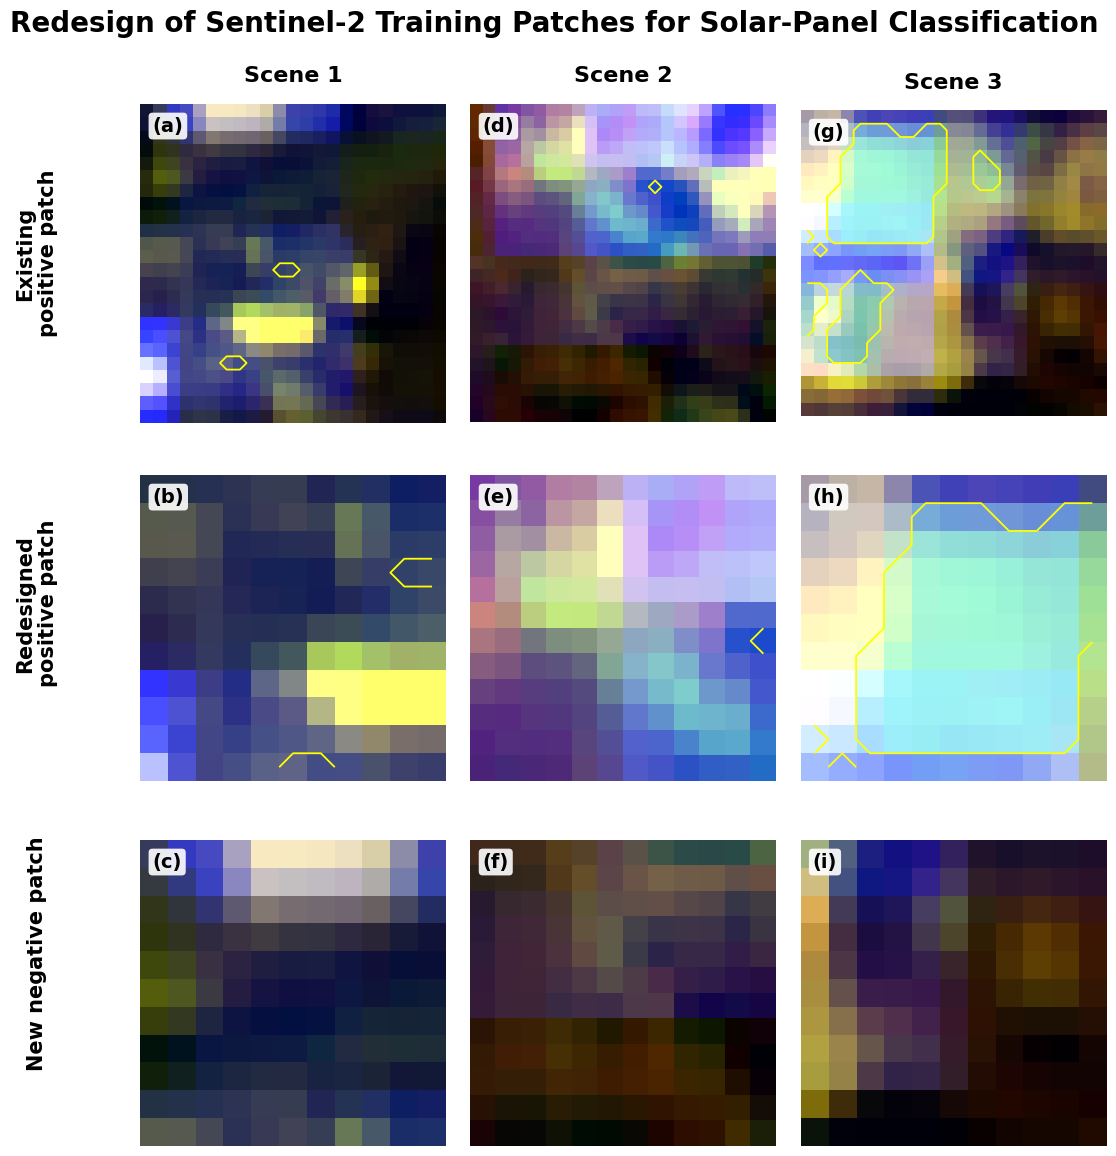

In [31]:
def stretch_rgb_q6(img_q6):
    img_q6 = img_q6.astype(np.float32)
    out_q6 = np.zeros_like(img_q6, dtype=np.float32)

    for b_q6 in range(img_q6.shape[2]):
        band_q6 = img_q6[:, :, b_q6]
        p2_q6, p98_q6 = np.percentile(band_q6, (2, 98))
        out_q6[:, :, b_q6] = np.clip((band_q6 - p2_q6) / (p98_q6 - p2_q6 + 1e-6), 0, 1)

    return out_q6

fig_q6, axes_q6 = plt.subplots(3, 3, figsize=(11.5, 12.5))

panel_labels_q6 = [
    "(a)", "(b)", "(c)",
    "(d)", "(e)", "(f)",
    "(g)", "(h)", "(i)"
]

panel_idx_q6 = 0

for col_q6, example_q6 in enumerate(figure_examples_q6[:3]):
    s2_path_q6 = example_q6["s2_path"]
    mask_path_q6 = example_q6["mask_path"]
    pos_bounds_q6 = example_q6["pos_bounds"]
    neg_bounds_q6 = example_q6["neg_bounds"]

    with rasterio.open(s2_path_q6) as src_q6:
        img_full_q6 = src_q6.read([3, 2, 1]).astype(np.float32)
        img_full_q6 = np.transpose(img_full_q6, (1, 2, 0))

    with rasterio.open(mask_path_q6) as src_q6:
        mask_full_q6 = (src_q6.read(1) > 0).astype(np.uint8)

    img_display_q6 = stretch_rgb_q6(img_full_q6)

    py0_q6, py1_q6, px0_q6, px1_q6 = pos_bounds_q6
    ny0_q6, ny1_q6, nx0_q6, nx1_q6 = neg_bounds_q6

    pos_img_q6 = img_display_q6[py0_q6:py1_q6, px0_q6:px1_q6, :]
    neg_img_q6 = img_display_q6[ny0_q6:ny1_q6, nx0_q6:nx1_q6, :]
    pos_mask_q6 = mask_full_q6[py0_q6:py1_q6, px0_q6:px1_q6]

    # ---------------- Row 1: Existing positive patch ----------------
    ax_q6 = axes_q6[0, col_q6]
    ax_q6.imshow(img_display_q6, interpolation="nearest")
    ax_q6.contour(mask_full_q6, levels=[0.5], colors="yellow", linewidths=1.3)
    ax_q6.set_title(
        f"Scene {col_q6 + 1}",
        fontsize=16,
        fontweight="bold",
        pad=16
    )
    ax_q6.axis("off")
    ax_q6.text(
        0.04, 0.96,
        panel_labels_q6[panel_idx_q6],
        transform=ax_q6.transAxes,
        fontsize=14,
        fontweight="bold",
        va="top",
        ha="left",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.9,
            boxstyle="round,pad=0.20"
        )
    )
    panel_idx_q6 += 1

    # ---------------- Row 2: Redesigned positive patch ----------------
    ax_q6 = axes_q6[1, col_q6]
    ax_q6.imshow(pos_img_q6, interpolation="nearest")
    ax_q6.contour(pos_mask_q6, levels=[0.5], colors="yellow", linewidths=1.3)
    ax_q6.axis("off")
    ax_q6.text(
        0.04, 0.96,
        panel_labels_q6[panel_idx_q6],
        transform=ax_q6.transAxes,
        fontsize=14,
        fontweight="bold",
        va="top",
        ha="left",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.9,
            boxstyle="round,pad=0.20"
        )
    )
    panel_idx_q6 += 1

    # ---------------- Row 3: New negative patch ----------------
    ax_q6 = axes_q6[2, col_q6]
    ax_q6.imshow(neg_img_q6, interpolation="nearest")
    ax_q6.axis("off")
    ax_q6.text(
        0.04, 0.96,
        panel_labels_q6[panel_idx_q6],
        transform=ax_q6.transAxes,
        fontsize=14,
        fontweight="bold",
        va="top",
        ha="left",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.9,
            boxstyle="round,pad=0.20"
        )
    )
    panel_idx_q6 += 1

# ---- Row labels: use line breaks to reduce overlap ----
row_labels_q6 = [
    "Existing\npositive patch",
    "Redesigned\npositive patch",
    "New negative patch"
]

row_y_q6 = [0.78, 0.50, 0.22]

for label_q6, y_q6 in zip(row_labels_q6, row_y_q6):
    fig_q6.text(
        0.05,
        y_q6,
        label_q6,
        rotation=90,
        va="center",
        ha="center",
        fontsize=15,
        fontweight="bold"
    )

fig_q6.suptitle(
    "Redesign of Sentinel-2 Training Patches for Solar-Panel Classification",
    fontsize=20,
    fontweight="bold",
    y=0.975
)

plt.subplots_adjust(
    left=0.14,
    right=0.98,
    top=0.90,
    bottom=0.06,
    wspace=0.08,
    hspace=0.14
)

plt.savefig(
    "Q6_training_patch_redesign.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.20
)

plt.show()

Q7: Exercise: re-run the model with your new training data (remembering that I am not looking for a total solution), and further adjusted hyperparameters/RAM options. Write two paragraphs that:

1. Sets out all the changes you have made and the reasoning for them.
2. Asses the training and model results in terms of performance statistics, commenting on how/if your training data changes have made an impact.

You may include figures to support your analysis if you wish, remembering to present them to publication standard if you do so.

## Code for Q7

**Approach:**
- **Use the full redesigned dataset:** Train on all nine Q6 training .npz files and both validation files, rather than restricting the workflow to a small subset as in the original workflow.

- **Simplify the data loader:** Replace the original mask-based loader with a direct loader because the redesigned samples are already resized to 128 x 128 and stored with final binary 0/1 labels.

- **Increase the mini-batch size:** Increase the training batch size from 4 to 8 to improve computational efficiency while remaining conservative with RAM usage.

- **Allow longer training:** Increase the maximum training duration from 5 to 25 epochs and raise Early Stopping patience from 3 to 4, giving the redesigned model more opportunity to converge while avoiding unnecessary overfitting.

- **Increase CNN capacity:** Expand the original two-layer CNN from 16/32 convolutional filters to three convolutional layers with 32/64/64 filters, add a second max-pooling layer, and increase the dense layer from 32 to 64 units so that the model can learn more complex spatial-spectral features.

- **Retain the core classification setup:** Keep Adam optimisation, binary cross-entropy loss, sigmoid output and the 0.5 classification threshold unchanged so that improvements can be attributed mainly to the redesigned data and increased model capacity.

- **Expand model evaluation:** Assess performance using precision, recall, specificity, F1-score and a confusion matrix in addition to loss and accuracy.

### Dataset training and settings

In [32]:
SEED_q7 = 42

TARGET_HEIGHT_q7 = 128
TARGET_WIDTH_q7 = 128
BANDS_q7 = BANDS_q6

BATCH_SIZE_q7 = 8
MAX_EPOCHS_q7 = 25
PATIENCE_q7 = 4

# Use all redesigned Q6 training and validation files instead of setting MAX_TRAIN_FILES
train_files_q7 = sorted(TRAIN_DIR_q6.glob("*.npz"))
val_files_q7 = sorted(VAL_DIR_q6.glob("*.npz"))

print(f"Q7 training NPZ files:   {len(train_files_q7)}")
print(f"Q7 validation NPZ files: {len(val_files_q7)}")
print(f"Q7 input channels:       {BANDS_q7}")

Q7 training NPZ files:   9
Q7 validation NPZ files: 2
Q7 input channels:       6


### Direct loader for redesigned data

The samples are already:

      X: (N, 128, 128, 6)
      Y: (N,)

In [33]:
def npz_loader_cls_q7(path_q7):
    path_q7 = path_q7.numpy().decode("utf-8")

    with np.load(path_q7) as data_q7:
        X_q7 = data_q7["X"].astype(np.float32)
        Y_q7 = data_q7["Y"].astype(np.float32)

    return X_q7, Y_q7

### Define training and validation datasets

In [34]:
# TensorFlow dataset pipeline

def tf_wrapper_q7(path_q7):
    X_q7, Y_q7 = tf.py_function(
        npz_loader_cls_q7,
        [path_q7],
        [tf.float32, tf.float32]
    )

    X_q7.set_shape([None, TARGET_HEIGHT_q7, TARGET_WIDTH_q7, BANDS_q7])
    Y_q7.set_shape([None])

    # Convert each NPZ file-batch into individual samples
    return tf.data.Dataset.from_tensor_slices((X_q7, Y_q7))


def make_cls_dataset_q7(
    file_list_q7,
    batch_size_q7=BATCH_SIZE_q7,
    shuffle_q7=True,
    repeat_q7=True
):

    file_strings_q7 = [str(f_q7) for f_q7 in file_list_q7]
    files_ds_q7 = tf.data.Dataset.from_tensor_slices(file_strings_q7)

    if shuffle_q7:
        files_ds_q7 = files_ds_q7.shuffle(
            len(file_strings_q7),
            seed=SEED_q7,
            reshuffle_each_iteration=True
        )

    # Stream samples from several NPZ files
    ds_q7 = files_ds_q7.interleave(
        lambda f_q7: tf_wrapper_q7(f_q7),
        cycle_length=4,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if shuffle_q7:
        ds_q7 = ds_q7.shuffle(1024, seed=SEED_q7, reshuffle_each_iteration=True)

    ds_q7 = ds_q7.batch(batch_size_q7, drop_remainder=False)
    ds_q7 = ds_q7.prefetch(tf.data.AUTOTUNE)

    if repeat_q7:
        ds_q7 = ds_q7.repeat()

    return ds_q7


train_ds_q7 = make_cls_dataset_q7(
    train_files_q7,
    batch_size_q7=BATCH_SIZE_q7,
    shuffle_q7=True,
    repeat_q7=True
)

val_ds_q7 = make_cls_dataset_q7(
    val_files_q7,
    batch_size_q7=BATCH_SIZE_q7,
    shuffle_q7=False,
    repeat_q7=False
)

Count samples and calculate steps.

In [35]:
def count_samples_q7(files_q7):

    total_q7 = 0

    for f_q7 in files_q7:
        with np.load(f_q7) as data_q7:
            total_q7 += data_q7["X"].shape[0]

    return total_q7


n_train_q7 = count_samples_q7(train_files_q7)
n_val_q7 = count_samples_q7(val_files_q7)

steps_per_epoch_q7 = max(1, math.ceil(n_train_q7 / BATCH_SIZE_q7))
validation_steps_q7 = max(1, math.ceil(n_val_q7 / BATCH_SIZE_q7))

print(f"Training samples:   {n_train_q7}")
print(f"Validation samples: {n_val_q7}")

print(f"\nBatch size: {BATCH_SIZE_q7}")
print(f"Steps per epoch: {steps_per_epoch_q7}")
print(f"Validation steps: {validation_steps_q7}")

Training samples:   842
Validation samples: 200

Batch size: 8
Steps per epoch: 106
Validation steps: 25


### Input sanity check

In [36]:
for X_batch_q7, Y_batch_q7 in train_ds_q7.take(1):

    print("X batch shape:", X_batch_q7.shape)
    print("Y batch shape:", Y_batch_q7.shape)

    print("\nBatch labels:")
    print(Y_batch_q7.numpy())

X batch shape: (8, 128, 128, 6)
Y batch shape: (8,)

Batch labels:
[0. 1. 1. 1. 0. 0. 1. 1.]


### Build a fresh CNN Model

In [37]:
tf.keras.backend.clear_session()

np.random.seed(SEED_q7)
tf.random.set_seed(SEED_q7)


def build_model_q7():
    inputs_q7 = layers.Input(shape=(TARGET_HEIGHT_q7, TARGET_WIDTH_q7, BANDS_q7))
    x_q7 = layers.Conv2D(32, 3, activation="relu", padding="same")(inputs_q7)
    x_q7 = layers.MaxPooling2D((2, 2))(x_q7)
    x_q7 = layers.Conv2D(64, 3, activation="relu", padding="same")(x_q7)
    # Additional MaxPooling
    x_q7 = layers.MaxPooling2D((2, 2))(x_q7)
    # Additional convolution layer
    x_q7 = layers.Conv2D(64, 3, activation="relu", padding="same")(x_q7)
    x_q7 = layers.GlobalAveragePooling2D()(x_q7)
    x_q7 = layers.Dense(64, activation="relu")(x_q7)
    outputs_q7 = layers.Dense(1, activation="sigmoid")(x_q7)
    model_q7 = models.Model(inputs_q7, outputs_q7)
    model_q7.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model_q7

model_q7 = build_model_q7()
model_q7.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 6)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │         1,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,409 (239.88 KB)

 Trainable params: 61,409 (239.88 KB)

 Non-trainable params: 0 (0.00 B)

### Traing the model on redesigned dataset

In [38]:
early_stopping_q7 = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=PATIENCE_q7,
    restore_best_weights=True,
    mode="min",
    verbose=1
)

history_q7 = model_q7.fit(
    train_ds_q7,
    steps_per_epoch=steps_per_epoch_q7,

    validation_data=val_ds_q7,
    validation_steps=validation_steps_q7,

    epochs=MAX_EPOCHS_q7,

    callbacks=[
        early_stopping_q7
    ]
)

Epoch 1/25
106/106 ━━━━━━━━━━━━━━━━━━━━ 39s 309ms/step - accuracy: 0.5819 - loss: 0.6753 - val_accuracy: 0.6050 - val_loss: 0.6494
Epoch 2/25
106/106 ━━━━━━━━━━━━━━━━━━━━ 32s 298ms/step - accuracy: 0.6580 - loss: 0.6101 - val_accuracy: 0.6750 - val_loss: 0.5792
Epoch 3/25
106/106 ━━━━━━━━━━━━━━━━━━━━ 32s 303ms/step - accuracy: 0.6888 - loss: 0.5778 - val_accuracy: 0.7050 - val_loss: 0.5674
Epoch 4/25
106/106 ━━━━━━━━━━━━━━━━━━━━ 39s 365ms/step - accuracy: 0.7126 - loss: 0.5500 - val_accuracy: 0.6950 - val_loss: 0.5763
Epoch 5/25
106/106 ━━━━━━━━━━━━━━━━━━━━ 41s 390ms/step - accuracy: 0.7411 - loss: 0.5197 - val_accuracy: 0.7450 - val_loss: 0.5260
Epoch 6/25
106/106 ━━━━━━━━━━━━━━━━━━━━ 41s 384ms/step - accuracy: 0.7470 - loss: 0.5138 - val_accuracy: 0.7800 - val_loss: 0.5185
Epoch 7/25
106/106 ━━━━━━━━━━━━━━━━━━━━ 41s 387ms/step - accuracy: 0.7447 - loss: 0.5097 - val_accuracy: 0.7700 - val_loss: 0.5206
Epoch 8/25
106/106 ━━━━━━━━━━━━━━━━━━━━ 41s 390ms/step - accuracy: 0.7470 - loss: 0

### Summarise training history

In [39]:
history_dict_q7 = history_q7.history

best_epoch_q7 = (np.argmin(history_dict_q7["val_loss"]) + 1)

print(f"Epochs completed: {len(history_dict_q7['loss'])}")
print(f"Best validation-loss epoch: {best_epoch_q7}")

print(
    f"\nFinal training loss: "
    f"{history_dict_q7['loss'][-1]:.4f}"
)

print(
    f"Final training accuracy: "
    f"{history_dict_q7['accuracy'][-1]:.4f}"
)

print(
    f"Final validation loss: "
    f"{history_dict_q7['val_loss'][-1]:.4f}"
)

print(
    f"Final validation accuracy: "
    f"{history_dict_q7['val_accuracy'][-1]:.4f}"
)

print(
    f"\nBest validation loss: "
    f"{min(history_dict_q7['val_loss']):.4f}"
)

Epochs completed: 25
Best validation-loss epoch: 25

Final training loss: 0.4337
Final training accuracy: 0.8052
Final validation loss: 0.4137
Final validation accuracy: 0.7900

Best validation loss: 0.4137


### Collect validation predictions

In [40]:
Y_true_q7 = []
Y_prob_q7 = []

for X_batch_q7, Y_batch_q7 in val_ds_q7:
    prob_batch_q7 = model_q7.predict(X_batch_q7, verbose=0).ravel()
    Y_true_q7.extend(Y_batch_q7.numpy())
    Y_prob_q7.extend(prob_batch_q7)

Y_true_q7 = np.asarray(Y_true_q7, dtype=np.int32)
Y_prob_q7 = np.asarray(Y_prob_q7, dtype=np.float32)

# Standard binary decision threshold
Y_pred_q7 = (Y_prob_q7 >= 0.5).astype(np.int32)

print("Validation samples evaluated:", len(Y_true_q7))
print("True positive samples:", np.sum(Y_true_q7 == 1))
print("True negative samples:", np.sum(Y_true_q7 == 0))

Validation samples evaluated: 200
True positive samples: 100
True negative samples: 100


### Validation performance

In [41]:
cm_q7 = confusion_matrix(Y_true_q7, Y_pred_q7)
tn_q7, fp_q7, fn_q7, tp_q7 = cm_q7.ravel()
accuracy_q7 = accuracy_score(Y_true_q7, Y_pred_q7)
precision_q7 = precision_score(Y_true_q7, Y_pred_q7, zero_division=0)
recall_q7 = recall_score(Y_true_q7, Y_pred_q7, zero_division=0)

specificity_q7 = (
    tn_q7 / (tn_q7 + fp_q7)
    if (tn_q7 + fp_q7) > 0
    else np.nan
)

f1_q7 = f1_score(Y_true_q7, Y_pred_q7, zero_division=0)

print("Validation confusion matrix:")
print(cm_q7)

print("\nValidation performance:")
print(f"Accuracy:    {accuracy_q7:.3f}")
print(f"Precision:   {precision_q7:.3f}")
print(f"Recall:      {recall_q7:.3f}")
print(f"Specificity: {specificity_q7:.3f}")
print(f"F1-score:    {f1_q7:.3f}")

print("\nConfusion-matrix counts:")
print(f"True negatives:  {tn_q7}")
print(f"False positives: {fp_q7}")
print(f"False negatives: {fn_q7}")
print(f"True positives:  {tp_q7}")

Validation confusion matrix:
[[87 13]
 [29 71]]

Validation performance:
Accuracy:    0.790
Precision:   0.845
Recall:      0.710
Specificity: 0.870
F1-score:    0.772

Confusion-matrix counts:
True negatives:  87
False positives: 13
False negatives: 29
True positives:  71


### Create a performance figure

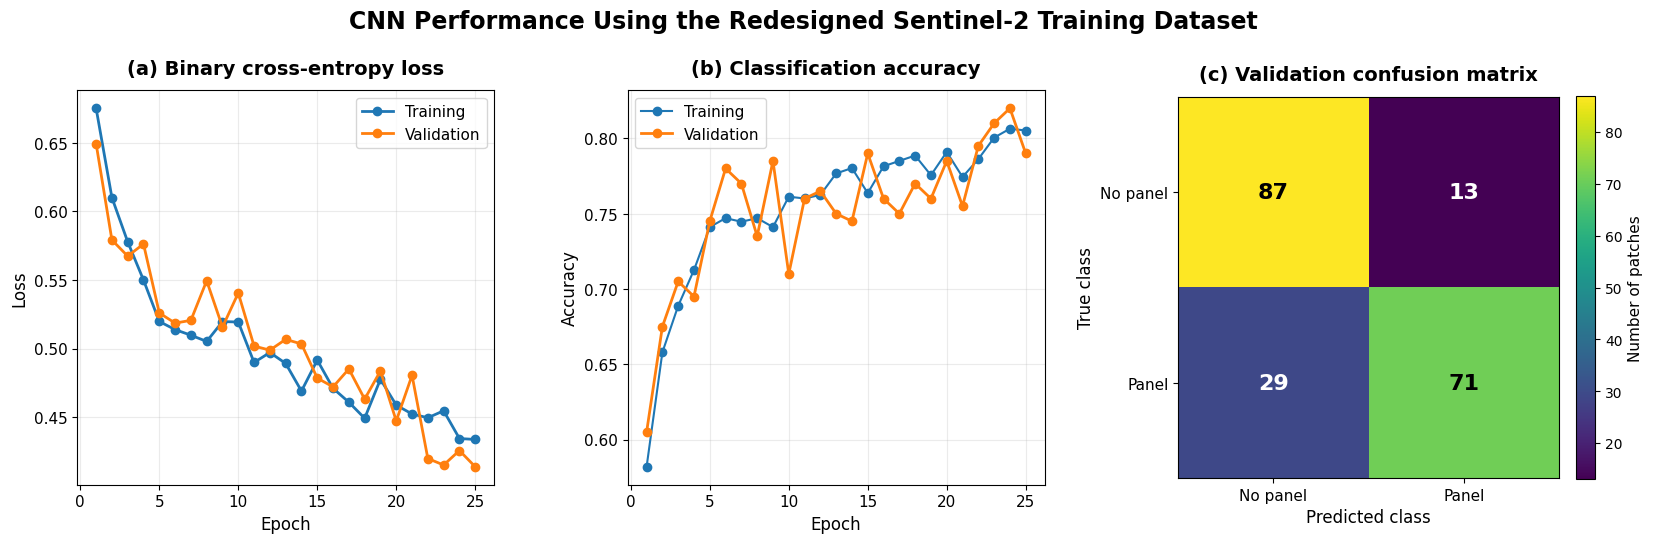

In [42]:
epochs_q7 = np.arange(1, len(history_dict_q7["loss"]) + 1)
fig_q7, axes_q7 = plt.subplots(1, 3, figsize=(16.5, 5.8))

# ---------------- (a) Loss ----------------
ax_q7 = axes_q7[0]
ax_q7.plot(epochs_q7, history_dict_q7["loss"], marker="o", linewidth=2, label="Training")
ax_q7.plot(epochs_q7, history_dict_q7["val_loss"], marker="o", linewidth=2, label="Validation")
ax_q7.set_title("(a) Binary cross-entropy loss", fontsize=14, fontweight="bold", pad=12)
ax_q7.set_xlabel("Epoch", fontsize=12)
ax_q7.set_ylabel("Loss", fontsize=12)
ax_q7.tick_params(axis="both", labelsize=11)
ax_q7.legend(fontsize=11, frameon=True)
ax_q7.grid(alpha=0.25)

# ---------------- (b) Accuracy ----------------
ax_q7 = axes_q7[1]
ax_q7.plot(epochs_q7, history_dict_q7["accuracy"], marker="o", label="Training")
ax_q7.plot(epochs_q7, history_dict_q7["val_accuracy"], marker="o", linewidth=2, label="Validation")
ax_q7.set_title("(b) Classification accuracy", fontsize=14, fontweight="bold", pad=12)
ax_q7.set_xlabel("Epoch", fontsize=12)
ax_q7.set_ylabel("Accuracy", fontsize=12)
ax_q7.tick_params(axis="both", labelsize=11)
ax_q7.legend(fontsize=11, frameon=True)
ax_q7.grid(alpha=0.25)

# ---------------- (c) Confusion matrix ----------------
ax_q7 = axes_q7[2]
im_q7 = ax_q7.imshow(cm_q7)
ax_q7.set_title("(c) Validation confusion matrix", fontsize=14, fontweight="bold", pad=12)
ax_q7.set_xlabel("Predicted class", fontsize=12)
ax_q7.set_ylabel("True class", fontsize=12)
ax_q7.set_xticks([0, 1])
ax_q7.set_yticks([0, 1])
ax_q7.set_xticklabels(["No panel", "Panel"], fontsize=11)
ax_q7.set_yticklabels(["No panel", "Panel"], fontsize=11)
threshold_q7 = cm_q7.max() / 2

for i_q7 in range(2):
    for j_q7 in range(2):
        ax_q7.text(
            j_q7,
            i_q7,
            str(cm_q7[i_q7, j_q7]),
            ha="center",
            va="center",
            fontsize=16,
            fontweight="bold",
            color="black" if cm_q7[i_q7, j_q7] > threshold_q7 else "white"
        )

cbar_q7 = fig_q7.colorbar(im_q7, ax=ax_q7, fraction=0.046, pad=0.04)
cbar_q7.ax.tick_params(labelsize=10)
cbar_q7.set_label("Number of patches", fontsize=11)

fig_q7.suptitle(
    "CNN Performance Using the Redesigned Sentinel-2 Training Dataset",
    fontsize=17,
    fontweight="bold",
    y=0.98
)

plt.subplots_adjust(
    left=0.06,
    right=0.98,
    top=0.84,
    bottom=0.16,
    wspace=0.32
)

plt.savefig(
    "Q7_CNN_performance_redesigned_training.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.18
)

plt.show()